In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

In [2]:
DTYPE='float32'
tf.keras.backend.set_floatx(DTYPE)
tf.random.set_seed(0)

In [3]:
def make_model(trainable = False, hidden_layers=4, neurons=32):
    """
    Function to develop the PINN model to train.

    string trainable: determines whether omega is fixed or has to be derived from data
    float hidden_layers: number of hidden layers
    float neurons: number of neurons for each layer.

    returns: 
    Sequential model: PINN model (not trained)
    """
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(1,)))
    for _ in range(hidden_layers):
        model.add(tf.keras.layers.Dense(neurons, activation="tanh"))

    model.add(tf.keras.layers.Dense(1))
    
    if trainable == True:
        model.omega = model.add_weight(
            name="omega",
            shape=(),
            dtype=tf.float32,
            initializer=tf.keras.initializers.Constant(1.),
            trainable=trainable,
        )
    else:
        model.omega = model.add_weight(
            name="omega",
            shape=(),
            dtype=tf.float32,
            initializer=tf.keras.initializers.Constant(2*np.pi),
            trainable=trainable,
        )
    print('Initialized omega = ', model.omega.numpy())
    return model

def first_derivative(model, t, tape):
    """
    Function to compute the derivative by using autodifferentiation.

    Sequential model: PINN model
    float t: time variable
    GradientTape tape: gradient by which it is possible to compute the derivative

    returns:
    float x: model prediction with respect to t
    float tape.gradient(x, t): first derivative
    """
    x = model(t)
    return x, tape.gradient(x, t)

def second_derivative(model, t):
    """
    Function to compute the derivatives by using autodifferentiation.

    Sequential model: PINN model
    float t: time variable

    returns:
    float x: model prediction with respect to t
    float x_t: first derivative
    float x_tt: second derivative 
    """
    with tf.GradientTape() as tape2:
        tape2.watch(t)
        with tf.GradientTape() as tape1:
            tape1.watch(t)
            x = model(t)

        x_t = tape1.gradient(x,t)
    x_tt = tape2.gradient(x_t, t)
    del tape2
    return x, x_t, x_tt

def loss_function(model, t, t0, trainable = False):
    """"
    Function to compute the loss for the model.

    Sequential model: PINN model
    float t: time variable
    float t0: initial time
    string trainable: determines whether omega is fixed or has to be derived from data

    returns:
    float loss: total loss for the model
    float physics_loss: residual between prediction and analytical solution
    float ic_loss: residual for IC (position and velocity)
    float ic_data: residual between prediction and simulated data
    """
    x, x_t, x_tt = second_derivative(model, t)
    res =  x_tt + model.omega**2*x

    with tf.GradientTape() as tape:
        tape.watch(t0)
        x0 = model(t0)
    x0_t = tape.gradient(x0, t0)

    physics_loss = tf.reduce_mean(tf.square(res))
    ic_loss = tf.reduce_mean(tf.square(x0-1.))+tf.reduce_mean(tf.square(x0_t-0.))
    loss = w_pde*physics_loss+w_ic*ic_loss
    omega_loss = 0.
    if trainable == True:
        x_pred_data = model(t_data, training=True) 
        omega_loss = tf.reduce_mean(tf.square(x_pred_data - x_data))
        loss = loss + w_data*omega_loss

    return loss, physics_loss, ic_loss, omega_loss

In [4]:
@tf.function
def train_step(model, t, t0, trainable = False):
    """
    Tensorflow function for training step of the model.

    Sequential model: PINN model
    float t: time variable
    float t0: initial time
    string trainable: determines whether omega is fixed or has to be derived from data

    returns:
    float loss: total loss for the model
    float loss_pde: residual between prediction and analytical solution
    float loss_ic: residual for IC (position and velocity)
    float loss_data: residual between prediction and simulated data
    """
    with tf.GradientTape() as tape:
        loss, loss_pde, loss_ic, loss_data = loss_function(model, t, t0, trainable=trainable)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss, loss_pde, loss_ic, loss_data

def train(trainable=False):
    """
    Function to train the model.

    returns:
    Sequential model: PINN model (trained)
    array (float) losses: 
        [total loss, residual between prediction and analytical solution,
         loss for ICs, residual between prediction and simulated data]
    """
    model = make_model(trainable=trainable)
    t = tf.constant(np.random.uniform(0, t1, Nr).reshape(-1, 1), dtype=tf.float32)
    t0 = tf.constant([[0.0]], dtype=tf.float32)
    losses = []
    for epoch in range(1, Nepochs + 1):
        loss, loss_pde, loss_ic, loss_data = train_step(model, t, t0, trainable=trainable)
        losses.append([float(loss), float(loss_pde), float(loss_ic), float(loss_data)])
        if epoch % 500 == 0:
            print(f"Epoch {epoch:5d} | total = {loss.numpy():.3e} | "
                f"physics = {loss_pde.numpy():.3e} | IC = {loss_ic.numpy():.3e} | "
                f"data = {loss_data.numpy():.3e} | omega = {model.omega.numpy():.3f} |")

    return model, losses

In [5]:
omega_true = 2*np.pi
t0, t1 = 0., 2.
Nr = 1000
Nepochs = 10000
t = tf.random.uniform((Nr, 1), t0, t1, dtype=DTYPE)
y0 = [1.] 

w_pde = 1.
w_ic = 10.

In [6]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model, losses = train()

Initialized omega =  6.2831855
Epoch   500 | total = 9.502e+00 | physics = 3.976e-01 | IC = 9.104e-01 | data = 0.000e+00 | omega = 6.283 |
Epoch  1000 | total = 9.456e+00 | physics = 4.031e-01 | IC = 9.053e-01 | data = 0.000e+00 | omega = 6.283 |
Epoch  1500 | total = 8.128e+00 | physics = 1.351e+00 | IC = 6.777e-01 | data = 0.000e+00 | omega = 6.283 |
Epoch  2000 | total = 7.929e+00 | physics = 1.458e+00 | IC = 6.472e-01 | data = 0.000e+00 | omega = 6.283 |
Epoch  2500 | total = 6.277e+00 | physics = 1.906e+00 | IC = 4.371e-01 | data = 0.000e+00 | omega = 6.283 |
Epoch  3000 | total = 3.744e+00 | physics = 1.633e+00 | IC = 2.111e-01 | data = 0.000e+00 | omega = 6.283 |
Epoch  3500 | total = 1.716e-01 | physics = 8.482e-02 | IC = 8.673e-03 | data = 0.000e+00 | omega = 6.283 |
Epoch  4000 | total = 2.576e-02 | physics = 2.238e-02 | IC = 3.385e-04 | data = 0.000e+00 | omega = 6.283 |
Epoch  4500 | total = 1.463e-02 | physics = 1.347e-02 | IC = 1.167e-04 | data = 0.000e+00 | omega = 6.283

In [7]:
t_test  = tf.constant(np.linspace(0, t1, 500).reshape(-1, 1), dtype=tf.float32)
t_np = np.linspace(0, t1, 500)
x_pred  = model(t_np).numpy().squeeze()
x_exact = np.cos(omega_true*t_np)
error = np.abs((x_pred-x_exact))
print(f'Maximum point-wise error: {np.max(error):.6f}')

Maximum point-wise error: 0.002606


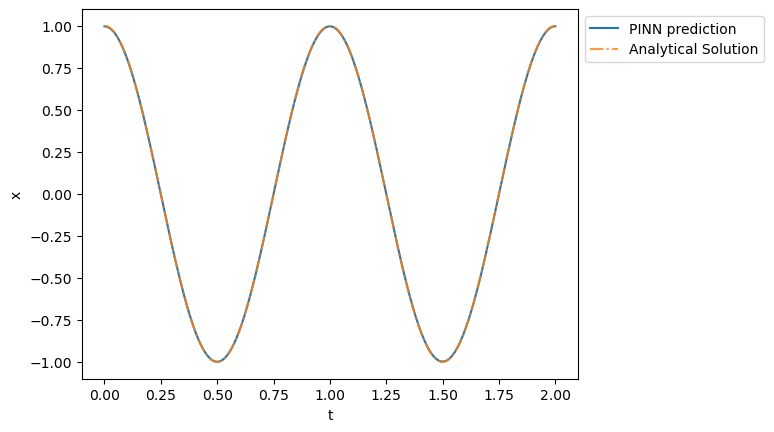

In [8]:
plt.plot(t_np, x_pred, label = 'PINN prediction')
plt.plot(t_np, x_exact,  alpha = 0.8, linestyle = '-.', label = 'Analytical Solution')
plt.xlabel('t')
plt.ylabel('x')
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

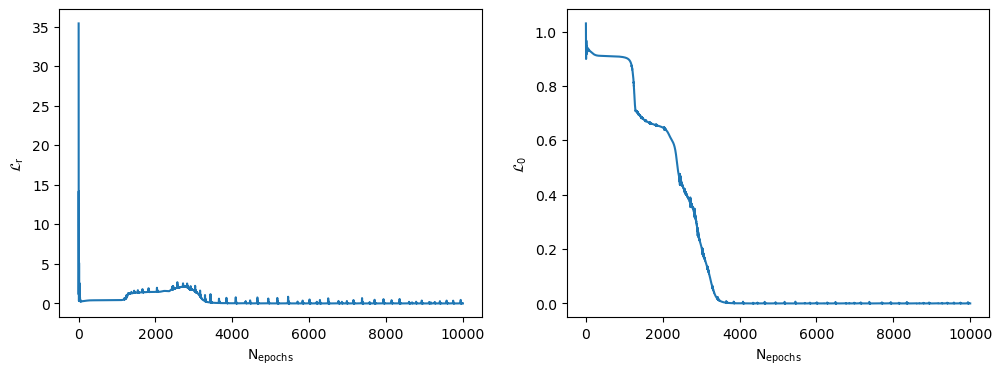

In [9]:
fig = plt.figure(figsize=(12,4))

losses = np.array(losses)
loss_r = losses[:, 1]
loss_0 = losses[:, 2]
epochs = np.arange(1, Nepochs+1)

ax = fig.add_subplot(121)
ax.plot(epochs, loss_r)
ax.set_xlabel(r'$\rm N_{epochs}$')
ax.set_ylabel(r'$\rm \mathcal{L}_{r}$')

ax = fig.add_subplot(122)
ax.plot(epochs, loss_0)
ax.set_xlabel(r'$\rm N_{epochs}$')
ax.set_ylabel(r'$\rm \mathcal{L}_{0}$')
plt.show()

In [10]:
t_break = 5.
t_test  = tf.constant(np.linspace(0, t_break, 500).reshape(-1, 1), dtype=tf.float32)
t_np = np.linspace(0, t_break, 500)
x_pred  = model(t_test).numpy().squeeze()
x_exact = np.cos(omega_true*t_np)
error = np.abs((x_pred-x_exact))
print(f'Maximum point-wise error: {np.max(error):.6f}')

Maximum point-wise error: 1.471429


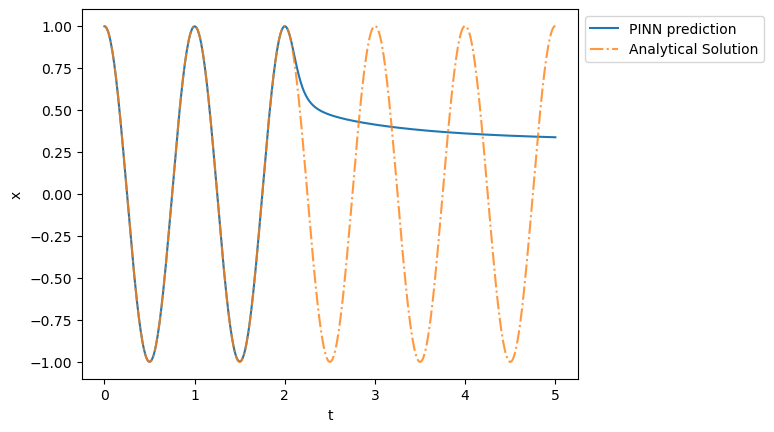

In [11]:
plt.plot(t_np, x_pred, label = 'PINN prediction')
plt.plot(t_np, x_exact,  alpha = 0.8, linestyle = '-.', label = 'Analytical Solution')
plt.xlabel('t')
plt.ylabel('x')
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

In [12]:
omega_true = 2*np.pi
t1 = 2*np.pi/omega_true
t_data = np.linspace(0, t1, 20).reshape(-1,1).astype(np.float32)
x_data = np.cos(omega_true*t_data) + np.float32(np.random.normal(0., 0.01, size = t_data.shape))

t_data = tf.constant(t_data)
x_data = tf.constant(x_data)

w_data = 100.

In [13]:
@tf.function
def train_step(model, t, t0, trainable = False):
    """
    Tensorflow function for training step of the model.

    Sequential model: PINN model
    float t: time variable
    float t0: initial time
    string trainable: determines whether omega is fixed or has to be derived from data

    returns:
    float loss: total loss for the model
    float loss_pde: residual between prediction and analytical solution
    float loss_ic: residual for IC (position and velocity)
    float loss_data: residual between prediction and simulated data
    """
    with tf.GradientTape() as tape:
        loss, loss_pde, loss_ic, loss_data = loss_function(model, t, t0, trainable=trainable)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss, loss_pde, loss_ic, loss_data

def train(trainable=False):
    """
    Function to train the model.

    returns:
    Sequential model: PINN model (trained)
    array (float) losses: 
        [total loss, residual between prediction and analytical solution,
         loss for ICs, residual between prediction and simulated data]
    """
    model = make_model(trainable=trainable)
    t = tf.constant(np.random.uniform(0, t1, Nr).reshape(-1, 1), dtype=tf.float32)
    t0 = tf.constant([[0.0]], dtype=tf.float32)
    losses = []
    for epoch in range(1, Nepochs + 1):
        loss, loss_pde, loss_ic, loss_data = train_step(model, t, t0, trainable=trainable)
        losses.append([float(loss), float(loss_pde), float(loss_ic), float(loss_data)])
        if epoch % 500 == 0:
            print(f"Epoch {epoch:5d} | total = {loss.numpy():.3e} | "
                f"physics = {loss_pde.numpy():.3e} | IC = {loss_ic.numpy():.3e} | "
                f"data = {loss_data.numpy():.3e} | omega = {model.omega.numpy():.3f} |")

    return model, losses

In [14]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model, losses = train(trainable=True)

Initialized omega =  1.0
Epoch   500 | total = 5.247e+01 | physics = 6.649e+00 | IC = 6.384e-01 | data = 3.943e-01 | omega = 1.363 |
Epoch  1000 | total = 5.120e+01 | physics = 7.759e+00 | IC = 6.445e-01 | data = 3.700e-01 | omega = 2.301 |
Epoch  1500 | total = 4.605e+01 | physics = 8.847e+00 | IC = 6.022e-01 | data = 3.118e-01 | omega = 3.348 |
Epoch  2000 | total = 3.243e+01 | physics = 8.238e+00 | IC = 3.749e-01 | data = 2.044e-01 | omega = 4.344 |
Epoch  2500 | total = 1.412e+01 | physics = 3.901e+00 | IC = 1.260e-01 | data = 8.957e-02 | omega = 5.161 |
Epoch  3000 | total = 4.216e+00 | physics = 8.147e-01 | IC = 4.087e-02 | data = 2.992e-02 | omega = 5.689 |
Epoch  3500 | total = 1.013e+00 | physics = 2.321e-01 | IC = 6.846e-03 | data = 7.129e-03 | omega = 5.992 |
Epoch  4000 | total = 1.991e-01 | physics = 4.680e-02 | IC = 1.185e-03 | data = 1.404e-03 | omega = 6.158 |
Epoch  4500 | total = 4.338e-02 | physics = 1.234e-02 | IC = 1.677e-04 | data = 2.936e-04 | omega = 6.238 |
Epo

Maximum point-wise error: 0.016879


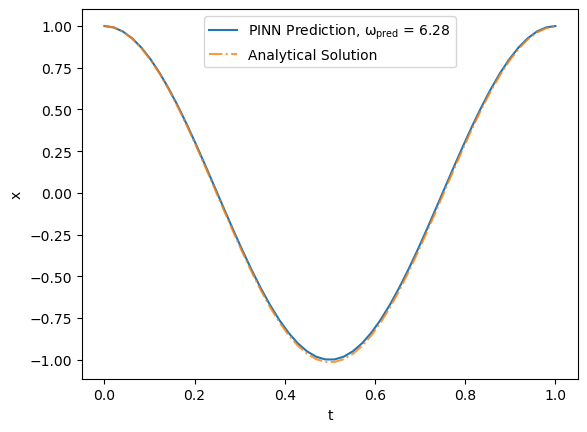

In [15]:
t_data_lin = tf.constant(np.linspace(0, t1))
x_data_lin = np.cos(omega_true*t_data_lin)
x_pred = model.predict(t_data_lin, verbose = False).squeeze()

error = np.abs((x_pred-x_data_lin))
print(f'Maximum point-wise error: {np.max(error):.6f}')

plt.plot(t_data_lin, x_data_lin, label = rf'PINN Prediction, $\rm \omega_{{pred}}$ = {model.omega.numpy():.2f}')
plt.plot(t_data_lin, x_pred, alpha = 0.8, linestyle = '-.', label = 'Analytical Solution')
plt.xlabel('t')
plt.ylabel('x')
plt.legend()
plt.show()

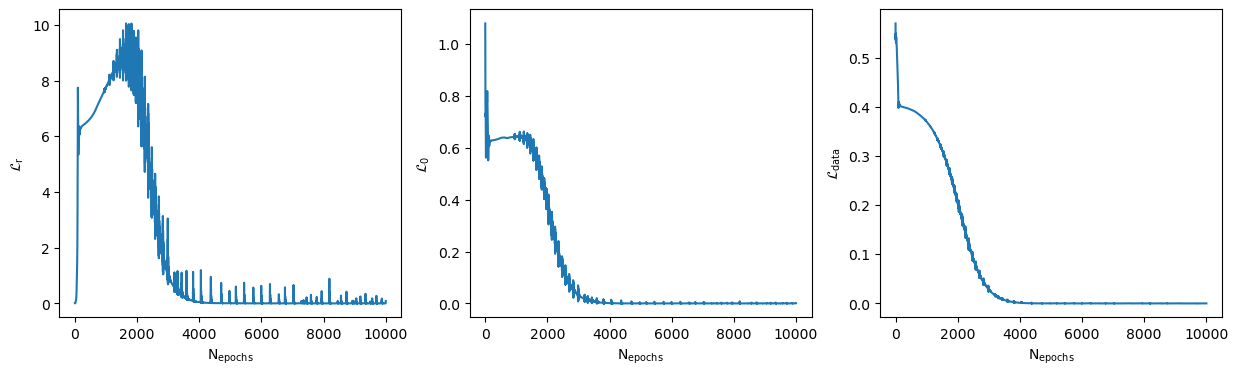

In [16]:
fig = plt.figure(figsize=(15,4))

losses = np.array(losses)
loss_r = losses[:, 1]
loss_0 = losses[:, 2]
loss_data = losses[:, 3]
epochs = np.arange(1, Nepochs+1)

ax = fig.add_subplot(131)
ax.plot(epochs, loss_r)
ax.set_xlabel(r'$\rm N_{epochs}$')
ax.set_ylabel(r'$\rm \mathcal{L}_{r}$')

ax = fig.add_subplot(132)
ax.plot(epochs, loss_0)
ax.set_xlabel(r'$\rm N_{epochs}$')
ax.set_ylabel(r'$\rm \mathcal{L}_{0}$')

ax = fig.add_subplot(133)
ax.plot(epochs, loss_data)
ax.set_xlabel(r'$\rm N_{epochs}$')
ax.set_ylabel(r'$\rm \mathcal{L}_{data}$')
plt.show()

In [17]:
def make_model_omega_tf(trainable = False, hidden_layers=4, neurons=32):
    """
    Function to develop the PINN model to train.

    string trainable: determines whether omega is fixed or has to be derived from data
    float hidden_layers: number of hidden layers
    float neurons: number of neurons for each layer.

    returns: 
    Sequential model: PINN model (not trained)
    """
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(1,)))
    for _ in range(hidden_layers):
        model.add(tf.keras.layers.Dense(neurons, activation="tanh"))

    model.add(tf.keras.layers.Dense(1))
    
    return model

def loss_function_omega_tf(model, t, t0, omega_tf, trainable = False):
    """"
    Function to compute the loss for the model.

    Sequential model: PINN model
    float t: time variable
    float t0: initial time
    tf.Variable (float) omega_tf: harmonic oscillator constant to determine
    string trainable: determines whether omega is fixed or has to be derived from data

    returns:
    float loss: total loss for the model
    float physics_loss: residual between prediction and analytical solution
    float ic_loss: residual for IC (position and velocity)
    float ic_data: residual between prediction and simulated data
    """
    x, x_t, x_tt = second_derivative(model, t)
    res =  x_tt + omega_tf**2*x

    with tf.GradientTape() as tape:
        tape.watch(t0)
        x0 = model(t0)
    x0_t = tape.gradient(x0, t0)

    physics_loss = tf.reduce_mean(tf.square(res))
    ic_loss = tf.reduce_mean(tf.square(x0-1.))+tf.reduce_mean(tf.square(x0_t-0.))
    loss = w_pde*physics_loss+w_ic*ic_loss
    omega_loss = 0.
    if trainable == True:
        x_pred_data = model(t_data, training=True) 
        omega_loss = tf.reduce_mean(tf.square(x_pred_data - x_data))
        loss = loss + w_data*omega_loss

    return loss, physics_loss, ic_loss, omega_loss

In [18]:
@tf.function
def train_step_omega_tf(model, t, t0, omega_tf,trainable = False):
    """
    Tensorflow function for training step of the model.

    Sequential model: PINN model
    float t: time variable
    float t0: initial time
    tf.Variable (float) omega_tf: harmonic oscillator constant to determine
    string trainable: determines whether omega is fixed or has to be derived from data

    returns:
    float loss: total loss for the model
    float loss_pde: residual between prediction and analytical solution
    float loss_ic: residual for IC (position and velocity)
    float loss_data: residual between prediction and simulated data
    """
    with tf.GradientTape() as tape:
        loss, loss_pde, loss_ic, loss_data = loss_function_omega_tf(model, t, t0, omega_tf, trainable=trainable)
    grads = tape.gradient(loss, [omega_tf] + model.trainable_variables)
    optimizer.apply_gradients(zip(grads, [omega_tf] + model.trainable_variables))
    return loss, loss_pde, loss_ic, loss_data

def train_omega_tf(trainable=False):
    """
    Function to train the model.

    returns:
    Sequential model: PINN model (trained)
    array (float) losses: 
        [total loss, residual between prediction and analytical solution,
         loss for ICs, residual between prediction and simulated data]
    """
    model = make_model_omega_tf(trainable=trainable)
    t = tf.constant(np.random.uniform(0, t1, Nr).reshape(-1, 1), dtype=tf.float32)
    t0 = tf.constant([[0.0]], dtype=tf.float32)
    losses = []
    for epoch in range(1, Nepochs + 1):
        loss, loss_pde, loss_ic, loss_data = train_step_omega_tf(model, t, t0, omega_tf, trainable=trainable)
        losses.append([float(loss), float(loss_pde), float(loss_ic), float(loss_data)])
        if epoch % 500 == 0:
            print(f"Epoch {epoch:5d} | total = {loss.numpy():.3e} | "
                f"physics = {loss_pde.numpy():.3e} | IC = {loss_ic.numpy():.3e} | "
                f"data = {loss_data.numpy():.3e} | omega = {omega_tf.numpy():.3f} |")

    return model, losses

In [19]:
omega_tf = tf.Variable(1., trainable=True, dtype = tf.float32)  
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model, losses = train_omega_tf(trainable=True)

Epoch   500 | total = 5.214e+01 | physics = 6.881e+00 | IC = 6.363e-01 | data = 3.890e-01 | omega = 1.371 |
Epoch  1000 | total = 5.088e+01 | physics = 7.958e+00 | IC = 6.348e-01 | data = 3.658e-01 | omega = 2.304 |
Epoch  1500 | total = 4.587e+01 | physics = 8.988e+00 | IC = 5.893e-01 | data = 3.099e-01 | omega = 3.334 |
Epoch  2000 | total = 3.239e+01 | physics = 8.062e+00 | IC = 3.834e-01 | data = 2.049e-01 | omega = 4.331 |
Epoch  2500 | total = 1.411e+01 | physics = 3.898e+00 | IC = 1.291e-01 | data = 8.918e-02 | omega = 5.154 |
Epoch  3000 | total = 4.186e+00 | physics = 1.062e+00 | IC = 3.107e-02 | data = 2.813e-02 | omega = 5.684 |
Epoch  3500 | total = 1.009e+00 | physics = 2.215e-01 | IC = 7.451e-03 | data = 7.132e-03 | omega = 5.990 |
Epoch  4000 | total = 1.973e-01 | physics = 3.877e-02 | IC = 1.476e-03 | data = 1.438e-03 | omega = 6.159 |
Epoch  4500 | total = 4.541e-02 | physics = 1.705e-02 | IC = 6.014e-05 | data = 2.776e-04 | omega = 6.239 |
Epoch  5000 | total = 1.778e

Maximum point-wise error: 0.005292


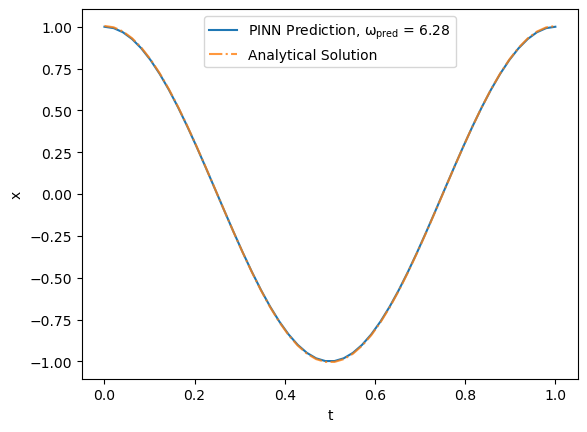

In [20]:
t_data_lin = tf.constant(np.linspace(0, t1))
x_data_lin = np.cos(omega_true*t_data_lin)
x_pred = model.predict(t_data_lin, verbose = False).squeeze()

error = np.abs((x_pred-x_data_lin))
print(f'Maximum point-wise error: {np.max(error):.6f}')

plt.plot(t_data_lin, x_data_lin, label = rf'PINN Prediction, $\rm \omega_{{pred}}$ = {omega_tf.numpy():.2f}')
plt.plot(t_data_lin, x_pred, alpha = 0.8, linestyle = '-.', label = 'Analytical Solution')
plt.xlabel('t')
plt.ylabel('x')
plt.legend()
plt.show()

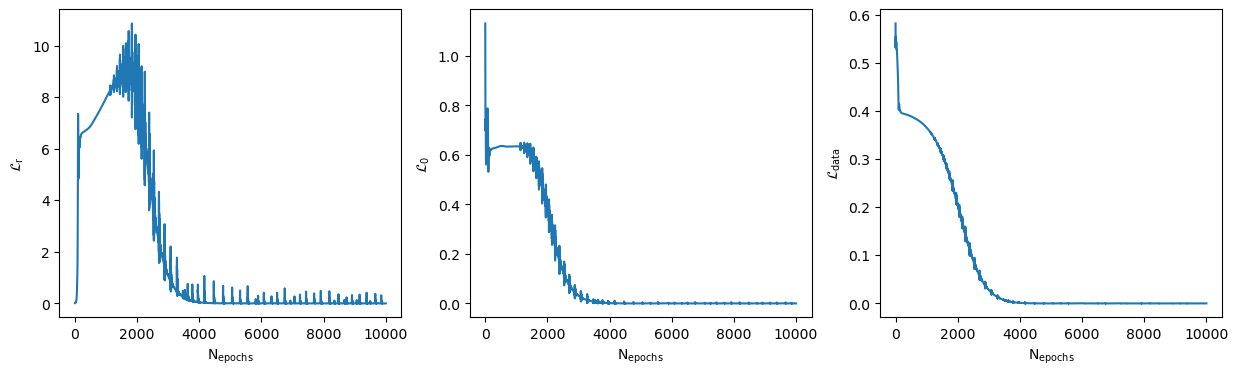

In [21]:
fig = plt.figure(figsize=(15,4))

losses = np.array(losses)
loss_r = losses[:, 1]
loss_0 = losses[:, 2]
loss_data = losses[:, 3]
epochs = np.arange(1, Nepochs+1)

ax = fig.add_subplot(131)
ax.plot(epochs, loss_r)
ax.set_xlabel(r'$\rm N_{epochs}$')
ax.set_ylabel(r'$\rm \mathcal{L}_{r}$')

ax = fig.add_subplot(132)
ax.plot(epochs, loss_0)
ax.set_xlabel(r'$\rm N_{epochs}$')
ax.set_ylabel(r'$\rm \mathcal{L}_{0}$')

ax = fig.add_subplot(133)
ax.plot(epochs, loss_data)
ax.set_xlabel(r'$\rm N_{epochs}$')
ax.set_ylabel(r'$\rm \mathcal{L}_{data}$')
plt.show()